In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps

sys.path.append("C:/Users/haoyu/Documents/GitHub/XRaySimulation")

from XRaySimulation import Pulse, DeviceSimu, util, Crystal

In [2]:
bLattice = np.zeros((11, 11, 11, 360, 3))

bLattice[:,:,:,:,0] = np.arange(-5, 6)[:, np.newaxis, np.newaxis, np.newaxis] * np.pi * 2 / 5.6578 * 1e4
bLattice[:,:,:,:,1] = np.arange(-5, 6)[np.newaxis, :, np.newaxis, np.newaxis] * np.pi * 2 / 5.6578 * 1e4
bLattice[:,:,:,:,2] = np.arange(-5, 6)[np.newaxis, np.newaxis, :, np.newaxis] * np.pi * 2 / 5.6578 * 1e4

tilt_angle = np.deg2rad(0)
tilt_mat = np.array([
    [1, 0, 0,],
    [0, np.cos(tilt_angle), -np.sin(tilt_angle)],
    [0, np.sin(tilt_angle), np.cos(tilt_angle)],
])

tilt_angle = -np.deg2rad(45)
tilt_mat = np.array([[np.cos(tilt_angle), -np.sin(tilt_angle), 0],
                     [np.sin(tilt_angle), np.cos(tilt_angle), 0],
                     [0, 0, 1,],    
                    ])


for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            for idx in range(360):
                angle_rot = np.deg2rad(idx)
                rot_mat = np.array([[1, 0, 0],
                                    [0, np.cos(angle_rot), -np.sin(angle_rot)],
                                    [0, np.sin(angle_rot), np.cos(angle_rot)],])
                
                bLattice[xIdx, yIdx, zIdx, idx, :] = np.dot(rot_mat, np.dot(tilt_mat, bLattice[xIdx, yIdx, zIdx, idx]))

In [7]:
kLen = util.kev_to_wavevec_length(9.8)
angle = np.deg2rad(11.639) * 2
kvec = np.array([0, -np.sin(angle), np.cos(angle)]) * kLen

tg_angle = np.deg2rad(0.00000156 * 2)
kvec_tg = np.copy(kvec)
kvec_tg[0] += 2 * np.sin(tg_angle) * kLen

In [8]:
kout = bLattice + kvec_tg[np.newaxis, np.newaxis, np.newaxis, np.newaxis]
kout_len = np.linalg.norm(kout, axis=-1)
kout_len_diff = kout_len - kLen

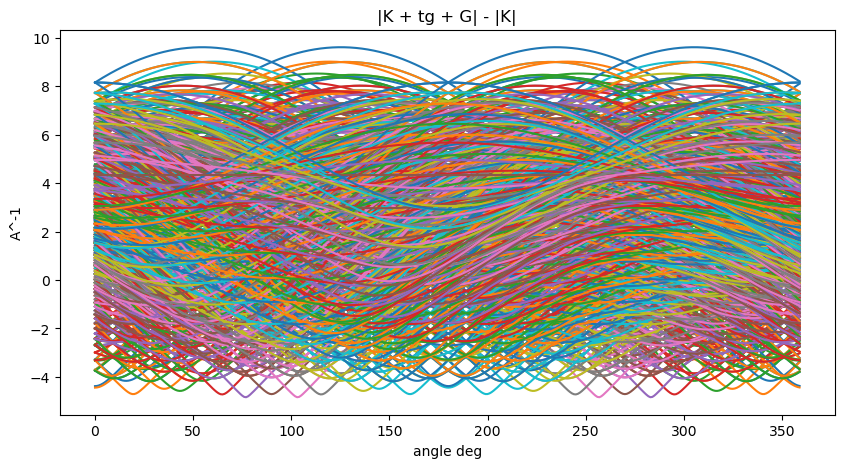

In [9]:
fig, ax = plt.subplots(ncols=1,nrows=1)
cmap = colormaps['summer']

fig.set_figheight(5)
fig.set_figwidth(10)

for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            ax.plot(np.arange(360), kout_len_diff[xIdx, yIdx, zIdx] / 1e4,
                    label="G=({}, {}, {})".format(xIdx, yIdx, zIdx))

plt.title('|K + tg + G| - |K|')
plt.ylabel("A^-1")
plt.xlabel('angle deg')
#plt.legend()
plt.show()

In [10]:
for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            x = np.argmin(np.abs(kout_len_diff[xIdx, yIdx, zIdx] / 1e4))
            k_tmp = kout[xIdx, yIdx, zIdx, x]

            if x == 359:
                continue
                
            if kout_len_diff[xIdx, yIdx, zIdx, x - 1] *  kout_len_diff[xIdx, yIdx, zIdx, x + 1] < 0:

                flag1 = (abs(xIdx - 5) % 2 == 1) and (abs(yIdx - 5) % 2 == 1) and (abs(zIdx - 5) % 2 == 1)
                flag2 = (abs(xIdx - 5) % 2 == 0) and (abs(yIdx - 5) % 2 == 0) and (abs(zIdx - 5) % 2 == 0)
                flag2 = flag2 and (abs(xIdx + yIdx + zIdx - 15) % 4 != 2)

                if flag1 or flag2:
                    #print(xIdx, yIdx, zIdx)

                    if k_tmp[0] > 0 and k_tmp[1] > 0 and k_tmp[2] > 0:
                
                        # Normalize the wave-vector
                        direction = k_tmp / np.linalg.norm(k_tmp)
                
                        # Get the position
                        position = direction / direction[2] * 12

                        # Impose the det position limitation
                        if position[0] < 18 and position[1]<14:
                            
                            #if xIdx - 5 >= 0 and yIdx - 5>= 0 and zIdx - 5>= 0 :

                            print("G=({}, {}, {})".format(xIdx - 5, yIdx - 5, zIdx - 5), kout[xIdx, yIdx, zIdx, x], x + 1 - 360)
                            print("detector positoin with respect to the sample in cm", position)
                            print('------------------------------')

G=(-2, 2, 0) [5.40880801e-03 2.98733272e+04 3.99573290e+04] -17
detector positoin with respect to the sample in cm [1.62437525e-06 8.97156881e+00 1.20000000e+01]
------------------------------
G=(-1, 1, -3) [5.40880801e-03 3.42076496e+04 3.60089579e+04] -316
detector positoin with respect to the sample in cm [1.80248749e-06 1.13997133e+01 1.20000000e+01]
------------------------------
G=(-1, 1, -1) [5.40880801e-03 1.88644928e+04 4.59064550e+04] -335
detector positoin with respect to the sample in cm [1.41386862e-06 4.93120006e+00 1.20000000e+01]
------------------------------
G=(-1, 3, -1) [15705.342954   30323.25290161 35863.04925256] -4
detector positoin with respect to the sample in cm [ 5.25510573 10.14634958 12.        ]
------------------------------
G=(0, 2, 2) [15705.342954   25350.41363528 39798.19451248] -75
detector positoin with respect to the sample in cm [ 4.7354941   7.64368754 12.        ]
------------------------------
G=(0, 4, 0) [31410.68049918 24410.67929312 29896.3